# 📰 Scraping MASSAL Berita Padel Indonesia
**Google News RSS + RSS Feed Langsung + Web Scraping**

Strategi: Gunakan RSS feed (paling reliable) + web scraping sebagai tambahan

In [ ]:
# !pip install requests beautifulsoup4 feedparser pandas lxml tqdm openpyxl -q

In [ ]:
# import requests
# from bs4 import BeautifulSoup
# import feedparser
# import pandas as pd
# from datetime import datetime
# import time, re, json, os, random
# from tqdm import tqdm
# from urllib.parse import quote_plus, urljoin
# import warnings
# warnings.filterwarnings('ignore')
# print('✅ Ready!')

## Konfigurasi MAKSIMAL

In [7]:
# 30+ keyword variasi untuk hasil maksimal
KEYWORDS = [
    'padel', 'padel Indonesia', 'olahraga padel', 'padel tennis',
    'lapangan padel', 'turnamen padel', 'padel court', 'padel Jakarta',
    'padel Surabaya', 'padel Bandung', 'padel Bali', 'padel Medan',
    'komunitas padel', 'klub padel', 'atlet padel Indonesia',
    'padel nasional', 'federasi padel', 'World Padel Tour Indonesia',
    'padel pemula', 'raket padel', 'peraturan padel', 'sejarah padel',
    'padel vs tenis', 'padel sport', 'padel trend Indonesia',
    'kompetisi padel', 'pelatih padel', 'padel indoor', 'padel outdoor',
    'bisnis padel', 'investasi padel', 'padel center',
    'padel booming', 'padel viral', 'padel populer',
    'lapangan padel Jakarta', 'harga padel', 'padel murah',
    'padel pro', 'padel event Indonesia'
]

HEADERS_LIST = [
    {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'},
    {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:121.0) Gecko/20100101 Firefox/121.0'},
    {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.2.1 Safari/605.1.15'},
]

REQUEST_DELAY = 1.5
OUTPUT_DIR = 'data'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'🔑 {len(KEYWORDS)} keywords siap digunakan')

🔑 40 keywords siap digunakan


## Helper Functions

In [8]:
def clean_text(text):
    if not text: return ''
    text = re.sub(r'<[^>]+>', '', str(text))
    return re.sub(r'\s+', ' ', text).strip()

def get_headers():
    return random.choice(HEADERS_LIST)

def safe_request(url, timeout=20):
    try:
        r = requests.get(url, headers=get_headers(), timeout=timeout, verify=False)
        r.raise_for_status()
        return r
    except Exception as e:
        return None

def extract_article_content(url):
    r = safe_request(url)
    if not r: return ''
    soup = BeautifulSoup(r.text, 'lxml')
    for tag in soup.find_all(['script','style','nav','footer','header','aside']): tag.decompose()
    selectors = ['article','.detail__body-text','.read__content','.content-detail',
                 '.article-content','.post-content','.entry-content','[itemprop="articleBody"]',
                 '.itp_bodycontent','.detail-text','.article__content','.text-detail',
                 '.DetailCont','.content__body','.body-article']
    for sel in selectors:
        c = soup.select_one(sel)
        if c:
            text = ' '.join([p.get_text() for p in c.find_all('p')])
            if len(text) > 50: return clean_text(text)
    ps = soup.find_all('p')
    return clean_text(' '.join([p.get_text() for p in ps[:30]])) if ps else ''

print('✅ Helpers ready!')

✅ Helpers ready!


---
## METODE 1: Google News RSS (Sumber Utama - Paling Banyak Hasil)
Google News mengumpulkan berita dari SEMUA portal berita sekaligus. Ini sumber paling efektif.

In [9]:
def scrape_google_news(keyword, time_range='30d', max_results=100):
    articles = []
    url = f'https://news.google.com/rss/search?q={quote_plus(keyword)}+when:{time_range}&hl=id&gl=ID&ceid=ID:id'
    feed = feedparser.parse(url)
    for entry in feed.entries[:max_results]:
        try:
            pub = ''
            try: pub = datetime(*entry.published_parsed[:6]).strftime('%Y-%m-%d %H:%M:%S')
            except: pub = entry.get('published','')
            articles.append({
                'judul': clean_text(entry.get('title','')),
                'url': entry.get('link',''),
                'sumber': entry.get('source',{}).get('title','Unknown'),
                'tanggal': pub,
                'ringkasan': clean_text(entry.get('summary','')),
                'keyword': keyword,
                'metode_scraping': f'google_news_{time_range}'
            })
        except: continue
    return articles

# Scrape dengan BANYAK time range untuk hasil MAKSIMAL
all_google = []
time_ranges = ['7d', '30d', '90d', '180d', '365d']

for tr in time_ranges:
    print(f'\n⏰ Google News - Time range: {tr}')
    for kw in tqdm(KEYWORDS, desc=f'Google News ({tr})'):
        arts = scrape_google_news(kw, tr, max_results=100)
        all_google.extend(arts)
        time.sleep(REQUEST_DELAY)
    print(f'   Running total: {len(all_google)}')

print(f'\n📊 Total Google News (sebelum dedup): {len(all_google)}')


⏰ Google News - Time range: 7d


Google News (7d): 100%|██████████| 40/40 [01:25<00:00,  2.14s/it]


   Running total: 2017

⏰ Google News - Time range: 30d


Google News (30d): 100%|██████████| 40/40 [01:27<00:00,  2.19s/it]


   Running total: 4483

⏰ Google News - Time range: 90d


...

   Running total: 7510

⏰ Google News - Time range: 180d


Google News (180d): 100%|██████████| 40/40 [01:42<00:00,  2.55s/it]


   Running total: 10848

⏰ Google News - Time range: 365d


Google News (365d): 100%|██████████| 40/40 [01:31<00:00,  2.29s/it]

   Running total: 14400

📊 Total Google News (sebelum dedup): 14400


---
## METODE 2: RSS Feed Langsung dari Portal Berita
Banyak situs berita punya RSS feed - lebih reliable daripada scraping HTML.

In [10]:
# RSS Feeds dari berbagai portal berita Indonesia
RSS_FEEDS = {
    'Detik Sport': 'https://rss.detik.com/index.php/sport',
    'Detik News': 'https://rss.detik.com/index.php/detikcom',
    'Detik Hot': 'https://rss.detik.com/index.php/hot',
    'Detik Finance': 'https://rss.detik.com/index.php/finance',
    'Kompas': 'https://rss.kompas.com/kompas-cetak',
    'Kompas Bola': 'https://rss.kompas.com/bola',
    'Kompas Sport': 'https://rss.kompas.com/olahraga',
    'Kompas Lifestyle': 'https://rss.kompas.com/lifestyle',
    'Kompas Properti': 'https://rss.kompas.com/properti',
    'Tribunnews': 'https://www.tribunnews.com/rss',
    'Tempo': 'https://rss.tempo.co/nasional',
    'Tempo Bisnis': 'https://rss.tempo.co/bisnis',
    'Liputan6': 'https://rss.liputan6.com/rss',
    'Antara': 'https://www.antaranews.com/rss/terkini',
    'Antara Olahraga': 'https://www.antaranews.com/rss/olahraga',
    'CNN Indonesia': 'https://www.cnnindonesia.com/rss',
    'CNBC Indonesia': 'https://www.cnbcindonesia.com/rss',
    'Suara': 'https://www.suara.com/rss',
    'Republika': 'https://www.republika.co.id/rss',
    'Bisnis': 'https://www.bisnis.com/rss',
    'Kumparan': 'https://kumparan.com/rss',
    'Okezone Sport': 'https://sindikasi.okezone.com/index.php/rss/1/RSS2.0',
    'Viva': 'https://www.viva.co.id/get/all',
    'iNews': 'https://www.inews.id/rss',
    'Bola.com': 'https://www.bola.com/rss',
    'Bola.net': 'https://www.bola.net/feed/',
    'Merdeka': 'https://www.merdeka.com/feed/',
    'Sindonews': 'https://index.sindonews.com/feed',
}

def scrape_rss_for_padel(feed_name, feed_url, keywords_lower):
    """Ambil artikel dari RSS feed yang mengandung keyword padel."""
    articles = []
    try:
        feed = feedparser.parse(feed_url)
        for entry in feed.entries:
            title = clean_text(entry.get('title', ''))
            summary = clean_text(entry.get('summary', '') or entry.get('description', ''))
            combined = (title + ' ' + summary).lower()

            # Cek apakah artikel mengandung keyword padel
            matched_kw = None
            for kw in keywords_lower:
                if kw in combined:
                    matched_kw = kw
                    break

            if matched_kw:
                pub = ''
                try: pub = datetime(*entry.published_parsed[:6]).strftime('%Y-%m-%d %H:%M:%S')
                except: pub = entry.get('published', '')

                articles.append({
                    'judul': title,
                    'url': entry.get('link', ''),
                    'sumber': feed_name,
                    'tanggal': pub,
                    'ringkasan': summary,
                    'keyword': matched_kw,
                    'metode_scraping': 'rss_feed'
                })
    except Exception as e:
        pass
    return articles

# Filter keywords untuk matching
keywords_lower = [kw.lower() for kw in KEYWORDS]
# Pastikan 'padel' selalu ada di awal
if 'padel' not in keywords_lower:
    keywords_lower.insert(0, 'padel')

all_rss = []
print('📡 Scraping RSS Feeds dari portal berita...')
for feed_name, feed_url in tqdm(RSS_FEEDS.items(), desc='RSS Feeds'):
    arts = scrape_rss_for_padel(feed_name, feed_url, keywords_lower)
    all_rss.extend(arts)
    time.sleep(0.5)

print(f'\n📊 Total dari RSS Feeds: {len(all_rss)}')
if all_rss:
    rss_df = pd.DataFrame(all_rss)
    print(rss_df['sumber'].value_counts().to_string())

📡 Scraping RSS Feeds dari portal berita...


RSS Feeds: 100%|██████████| 28/28 [00:38<00:00,  1.36s/it]


📊 Total dari RSS Feeds: 4
sumber
Tempo            2
CNN Indonesia    1
Okezone Sport    1


---
## METODE 3: Web Scraping dari Search Page
Scraping langsung dari halaman pencarian situs berita.

In [11]:
def scrape_detik(keyword, max_pages=10):
    articles = []
    for page in range(1, max_pages + 1):
        url = f'https://www.detik.com/search/searchall?query={quote_plus(keyword)}&page={page}&sortby=time'
        r = safe_request(url)
        if not r: continue
        soup = BeautifulSoup(r.text, 'lxml')
        # Detik search uses various structures; try multiple approaches
        found = False
        # Method 1: Find all links that look like article links
        for a in soup.find_all('a', href=True):
            href = a.get('href', '')
            title = clean_text(a.get_text())
            # Filter: must be a detik article URL and have substantial title
            if title and len(title) > 15 and ('detik.com' in href or '20.detik.com' in href):
                if '/d-' in href or '/detikupdate/' in href or '/berita/' in href or '/foto-news/' in href:
                    # Find date near this link
                    parent = a.parent
                    date_el = None
                    for p in [parent, parent.parent if parent else None]:
                        if p:
                            date_el = p.find(['time','span'], class_=lambda c: c and ('date' in str(c).lower() or 'time' in str(c).lower()))
                            if date_el: break
                    articles.append({
                        'judul': title, 'url': href,
                        'sumber': 'Detik.com',
                        'tanggal': clean_text(date_el.get_text()) if date_el else '',
                        'ringkasan': '',
                        'keyword': keyword,
                        'metode_scraping': 'detik_search'
                    })
                    found = True
        if not found: break
        time.sleep(REQUEST_DELAY)
    return articles

def scrape_kompas(keyword, max_pages=10):
    articles = []
    for page in range(1, max_pages + 1):
        url = f'https://search.kompas.com/search/?q={quote_plus(keyword)}&page={page}'
        r = safe_request(url)
        if not r: continue
        soup = BeautifulSoup(r.text, 'lxml')
        found = False
        for a in soup.find_all('a', href=True):
            href = a.get('href', '')
            title = clean_text(a.get_text())
            if title and len(title) > 15 and 'kompas.com' in href and '/read/' in href:
                parent = a.parent
                date_el = None
                for p in [parent, parent.parent if parent else None, parent.parent.parent if parent and parent.parent else None]:
                    if p:
                        date_el = p.find(['time','span','div'], class_=lambda c: c and ('date' in str(c).lower() or 'grey' in str(c).lower()))
                        if date_el: break
                articles.append({
                    'judul': title, 'url': href,
                    'sumber': 'Kompas.com',
                    'tanggal': clean_text(date_el.get_text()) if date_el else '',
                    'ringkasan': '',
                    'keyword': keyword,
                    'metode_scraping': 'kompas_search'
                })
                found = True
        if not found: break
        time.sleep(REQUEST_DELAY)
    return articles

def scrape_tribun(keyword, max_pages=10):
    articles = []
    for page in range(1, max_pages + 1):
        url = f'https://www.tribunnews.com/search?q={quote_plus(keyword)}&page={page}'
        r = safe_request(url)
        if not r: continue
        soup = BeautifulSoup(r.text, 'lxml')
        found = False
        for a in soup.find_all('a', href=True):
            href = a.get('href', '')
            title = clean_text(a.get_text())
            if title and len(title) > 15 and 'tribun' in href and not href.endswith('/search'):
                if not href.startswith('http'): href = urljoin('https://www.tribunnews.com', href)
                articles.append({
                    'judul': title, 'url': href,
                    'sumber': 'Tribunnews.com',
                    'tanggal': '',
                    'ringkasan': '',
                    'keyword': keyword,
                    'metode_scraping': 'tribun_search'
                })
                found = True
        if not found: break
        time.sleep(REQUEST_DELAY)
    return articles

def scrape_tempo(keyword, max_pages=10):
    articles = []
    for page in range(1, max_pages + 1):
        url = f'https://www.tempo.co/search?q={quote_plus(keyword)}&page={page}'
        r = safe_request(url)
        if not r: continue
        soup = BeautifulSoup(r.text, 'lxml')
        found = False
        for a in soup.find_all('a', href=True):
            href = a.get('href', '')
            title = clean_text(a.get_text())
            if title and len(title) > 15 and 'tempo.co' in href:
                articles.append({
                    'judul': title, 'url': href,
                    'sumber': 'Tempo.co',
                    'tanggal': '',
                    'ringkasan': '',
                    'keyword': keyword,
                    'metode_scraping': 'tempo_search'
                })
                found = True
        if not found: break
        time.sleep(REQUEST_DELAY)
    return articles

def scrape_cnnindonesia(keyword, max_pages=10):
    articles = []
    for page in range(1, max_pages + 1):
        url = f'https://www.cnnindonesia.com/search/?query={quote_plus(keyword)}&page={page}'
        r = safe_request(url)
        if not r: continue
        soup = BeautifulSoup(r.text, 'lxml')
        found = False
        for a in soup.find_all('a', href=True):
            href = a.get('href', '')
            title = clean_text(a.get_text())
            if title and len(title) > 15 and 'cnnindonesia.com' in href and '/' in href[30:]:
                if not href.startswith('http'): href = urljoin('https://www.cnnindonesia.com', href)
                articles.append({
                    'judul': title, 'url': href,
                    'sumber': 'CNN Indonesia',
                    'tanggal': '',
                    'ringkasan': '',
                    'keyword': keyword,
                    'metode_scraping': 'cnn_search'
                })
                found = True
        if not found: break
        time.sleep(REQUEST_DELAY)
    return articles

print('✅ Scrapers defined!')

✅ Scrapers defined!


In [12]:
# Jalankan web scraping untuk semua sumber
SCRAPERS = {
    'Detik': scrape_detik,
    'Kompas': scrape_kompas,
    'Tribunnews': scrape_tribun,
    'Tempo': scrape_tempo,
    'CNN Indonesia': scrape_cnnindonesia,
}

all_web_scrape = []
for site_name, scraper_fn in SCRAPERS.items():
    print(f'\n🌐 Scraping {site_name}...')
    site_total = 0
    for kw in tqdm(KEYWORDS, desc=site_name):
        arts = scraper_fn(kw, max_pages=10)
        all_web_scrape.extend(arts)
        site_total += len(arts)
        time.sleep(REQUEST_DELAY)
    print(f'   ✅ {site_name}: {site_total} artikel')

print(f'\n📊 Total Web Scraping: {len(all_web_scrape)}')


🌐 Scraping Detik...


Detik: 100%|██████████| 40/40 [01:00<00:00,  1.50s/it]


   ✅ Detik: 0 artikel

🌐 Scraping Kompas...


Kompas: 100%|██████████| 40/40 [01:00<00:00,  1.50s/it]


   ✅ Kompas: 0 artikel

🌐 Scraping Tribunnews...


...

   ✅ Tribunnews: 0 artikel

🌐 Scraping Tempo...


Tempo: 100%|██████████| 40/40 [01:00<00:00,  1.50s/it]


   ✅ Tempo: 0 artikel

🌐 Scraping CNN Indonesia...


CNN Indonesia: 100%|██████████| 40/40 [01:00<00:00,  1.50s/it]

   ✅ CNN Indonesia: 0 artikel

📊 Total Web Scraping: 0


---
## METODE 4: Bing News Search (Tambahan)
Bing News sebagai alternatif Google News - sumber berbeda, hasil berbeda.

In [13]:
def scrape_bing_news(keyword, max_pages=5):
    articles = []
    for page in range(max_pages):
        offset = page * 10
        url = f'https://www.bing.com/news/search?q={quote_plus(keyword)}+site:id&first={offset}&cc=id&setlang=id'
        r = safe_request(url)
        if not r: continue
        soup = BeautifulSoup(r.text, 'lxml')
        for a in soup.find_all('a', href=True):
            href = a.get('href', '')
            title = clean_text(a.get_text())
            if title and len(title) > 20 and ('http' in href) and ('bing.com' not in href) and ('microsoft' not in href):
                articles.append({
                    'judul': title, 'url': href,
                    'sumber': 'Bing News',
                    'tanggal': '',
                    'ringkasan': '',
                    'keyword': keyword,
                    'metode_scraping': 'bing_news'
                })
        time.sleep(REQUEST_DELAY)
    return articles

all_bing = []
print('🔎 Scraping Bing News...')
for kw in tqdm(KEYWORDS, desc='Bing News'):
    all_bing.extend(scrape_bing_news(kw, max_pages=5))
    time.sleep(REQUEST_DELAY)

print(f'📊 Total Bing News: {len(all_bing)}')

🔎 Scraping Bing News...


Bing News: 100%|██████████| 40/40 [01:00<00:00,  1.50s/it]

📊 Total Bing News: 0


---
## Gabungkan SEMUA Data & Deduplikasi

In [14]:
all_articles = []
all_articles.extend(all_google)
all_articles.extend(all_rss)
all_articles.extend(all_web_scrape)
all_articles.extend(all_bing)

print(f'📊 TOTAL SEBELUM deduplikasi: {len(all_articles)}')
print(f'   Google News RSS : {len(all_google)}')
print(f'   RSS Feeds       : {len(all_rss)}')
print(f'   Web Scraping    : {len(all_web_scrape)}')
print(f'   Bing News       : {len(all_bing)}')

df = pd.DataFrame(all_articles)
df = df.drop_duplicates(subset=['url'], keep='first')
df = df.drop_duplicates(subset=['judul'], keep='first')
df = df.reset_index(drop=True)

print(f'\n✅ TOTAL SETELAH deduplikasi: {len(df)}')
print(f'🗑️ Duplikat: {len(all_articles) - len(df)}')
print(f'\nDistribusi sumber:')
print(df['sumber'].value_counts().head(20).to_string())

📊 TOTAL SEBELUM deduplikasi: 14404
   Google News RSS : 14400
   RSS Feeds       : 4
   Web Scraping    : 0
   Bing News       : 0

✅ TOTAL SETELAH deduplikasi: 3646
🗑️ Duplikat: 10758

Distribusi sumber:
sumber
Bolasport.com      153
tvOneNews          151
Kompas.com          97
HarianBasis.co      73
Kumparan.com        67
Liputan6.com        65
MetroTVNews.com     63
Suara.com           55
RRI.co.id           51
detikcom            51
MSN                 48
detikNews           48
ANTARA News         46
detiksport          46
Jawa Pos            44
AsatuNews.co.id     43
Sultra Media        43
Kompas.tv           39
Tempo.co            38
CNN Indonesia       37


---
## Ekstrak Konten Artikel (Opsional)

In [15]:
EXTRACT_CONTENT = True

if EXTRACT_CONTENT:
    print(f'📝 Extracting content dari {len(df)} artikel...')
    print(f'⏱️ Estimasi: ~{len(df)*REQUEST_DELAY/60:.0f} menit')
    contents = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Extracting'):
        if 'news.google.com' in row['url']:
            contents.append(row.get('ringkasan',''))
        else:
            contents.append(extract_article_content(row['url']))
            time.sleep(REQUEST_DELAY)
    df['konten'] = contents
    ok = df['konten'].apply(lambda x: len(str(x)) > 50).sum()
    print(f'✅ {ok}/{len(df)} berhasil diekstrak')
else:
    df['konten'] = ''
    print('⏭️ Skipped - set EXTRACT_CONTENT = True untuk aktifkan')

📝 Extracting content dari 3646 artikel...
⏱️ Estimasi: ~91 menit


Extracting: 100%|██████████| 3646/3646 [00:06<00:00, 593.33it/s]  

✅ 3633/3646 berhasil diekstrak


---
## Preview & Simpan

In [16]:
print(f'📊 Dataset: {len(df)} baris x {len(df.columns)} kolom')
print(f'\n📰 Sumber berita ({df["sumber"].nunique()} sumber):')
print(df['sumber'].value_counts().to_string())
print(f'\n🔑 Top Keywords:')
print(df['keyword'].value_counts().head(15).to_string())
print(f'\n📋 Metode scraping:')
print(df['metode_scraping'].value_counts().to_string())
df[['judul','sumber','tanggal','keyword']].head(15)

📊 Dataset: 3646 baris x 8 kolom

📰 Sumber berita (807 sumber):
sumber
Bolasport.com                                   153
tvOneNews                                       151
Kompas.com                                       97
HarianBasis.co                                   73
Kumparan.com                                     67
Liputan6.com                                     65
MetroTVNews.com                                  63
Suara.com                                        55
RRI.co.id                                        51
detikcom                                         51
MSN                                              48
detikNews                                        48
ANTARA News                                      46
detiksport                                       46
Jawa Pos                                         44
AsatuNews.co.id                                  43
Sultra Media                                     43
Kompas.tv                                     

,judul,sumber,tanggal,keyword
0,"5 Aturan Baru Padel di Jakarta, Lapangan Baru ...",detikNews,2026-02-25 00:34:53,padel
1,Pemprov DKI Melarang Lapangan Padel Dibangun d...,Tribrata News,2026-02-24 07:33:00,padel
2,Pihak RT Ungkap Awal Mula Keluarnya Izin Lapan...,Kumparan.com,2026-02-20 11:07:00,padel
3,Duduk Perkara Protes Warga soal Lapangan Padel...,Tempo.co,2026-02-21 08:32:25,padel
4,Pramono Larang Pembangunan Lapangan Padel Baru...,Beritajakarta.id,2026-02-24 05:03:44,padel
5,Pemprov DKI Larang Pembangunan Lapangan Padel ...,Hukumonline,2026-02-25 03:24:22,padel
6,"Pramono Batasi Operasional Lapangan Padel, Mak...",CNN Indonesia,2026-02-24 05:13:33,padel
7,Mengapa Gubernur Jakarta Melarang Izin Lapanga...,Kompas.id,2026-02-25 01:00:00,padel
8,"Dikeluhkan Warga Jaksel, Begini Kebisingan Pad...",detikNews,2026-02-19 10:07:24,padel
9,Penataan Padel Dinilai Perkuat Iklim Usaha dan...,Beritajakarta.id,2026-02-25 00:05:00,padel


In [17]:
ts = datetime.now().strftime('%Y%m%d_%H%M%S')

csv_f = os.path.join(OUTPUT_DIR, f'berita_padel_{ts}.csv')
df.to_csv(csv_f, index=False, encoding='utf-8-sig')
print(f'✅ CSV: {csv_f}')

try:
    xlsx_f = os.path.join(OUTPUT_DIR, f'berita_padel_{ts}.xlsx')
    df.to_excel(xlsx_f, index=False)
    print(f'✅ XLSX: {xlsx_f}')
except: pass

json_f = os.path.join(OUTPUT_DIR, f'berita_padel_{ts}.json')
df.to_json(json_f, orient='records', force_ascii=False, indent=2)
print(f'✅ JSON: {json_f}')

print(f'\n🎉 {len(df)} artikel tersimpan!')

✅ CSV: data\berita_padel_20260225_225500.csv
✅ XLSX: data\berita_padel_20260225_225500.xlsx
✅ JSON: data\berita_padel_20260225_225500.json

🎉 3646 artikel tersimpan!


---
## Visualisasi

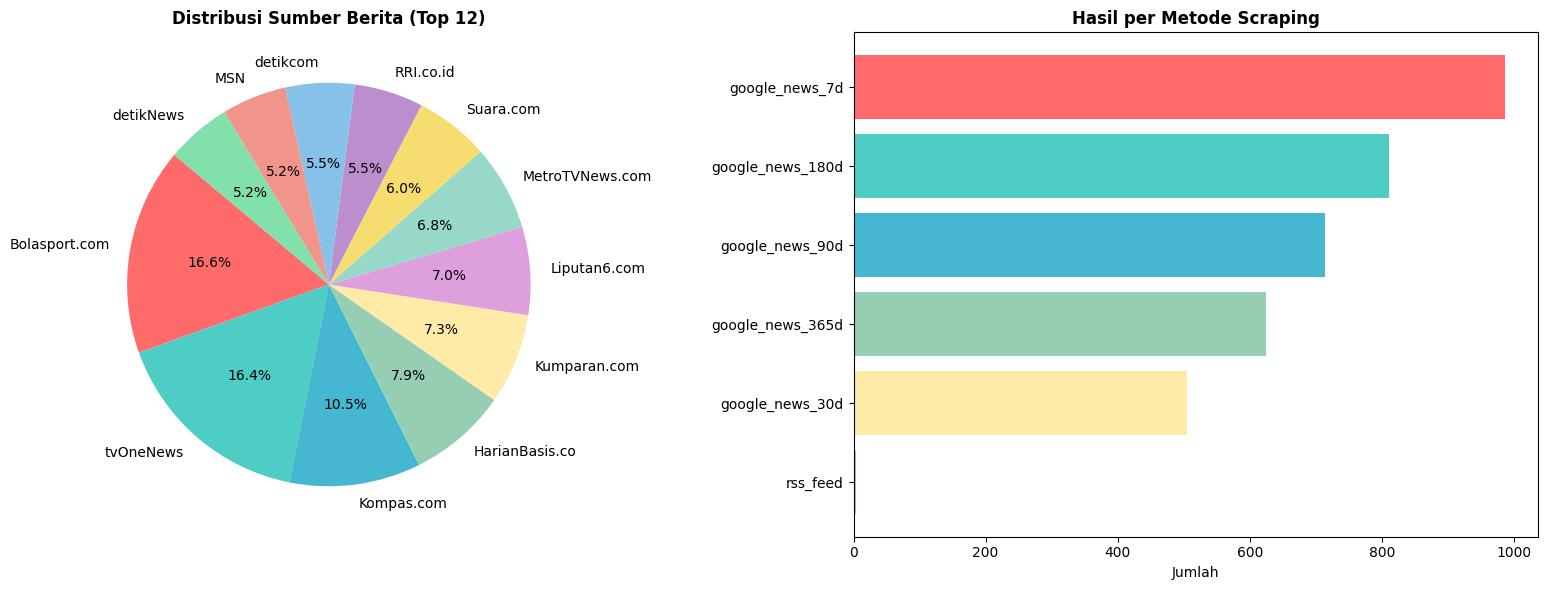

In [18]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = df['sumber'].value_counts().head(12)
colors = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#DDA0DD','#98D8C8','#F7DC6F','#BB8FCE','#85C1E9','#F1948A','#82E0AA']
axes[0].pie(sc.values, labels=sc.index, autopct='%1.1f%%', colors=colors[:len(sc)], startangle=140)
axes[0].set_title('Distribusi Sumber Berita (Top 12)', fontweight='bold')

mc = df['metode_scraping'].value_counts()
axes[1].barh(mc.index, mc.values, color=colors[:len(mc)])
axes[1].set_xlabel('Jumlah')
axes[1].set_title('Hasil per Metode Scraping', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distribusi_berita.png'), dpi=150, bbox_inches='tight')
plt.show()

In [19]:
print('='*60)
print('🎉 SCRAPING MASSAL SELESAI!')
print('='*60)
print(f'\n📊 Total artikel unik : {len(df)}')
print(f'📰 Jumlah sumber      : {df["sumber"].nunique()}')
print(f'🔑 Jumlah keyword     : {df["keyword"].nunique()}')
print(f'\n📁 Output: {OUTPUT_DIR}/')
print(f'\n🔮 Next steps:')
print(f'   1. Preprocessing (cleaning, tokenisasi, stopword removal)')
print(f'   2. Labeling sentimen (positif/negatif/netral)')
print(f'   3. Analisis sentimen (NLP model)')
print(f'   4. Visualisasi hasil')

🎉 SCRAPING MASSAL SELESAI!

📊 Total artikel unik : 3646
📰 Jumlah sumber      : 807
🔑 Jumlah keyword     : 40

📁 Output: data/

🔮 Next steps:
   1. Preprocessing (cleaning, tokenisasi, stopword removal)
   2. Labeling sentimen (positif/negatif/netral)
   3. Analisis sentimen (NLP model)
   4. Visualisasi hasil
